## Step 1: Mount Google Drive and Extract Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

zip_path = '/content/drive/MyDrive/DLHT1/archive.zip'
!unzip -q "{zip_path}" -d /content/cell-images-for-detecting-malaria


Mounted at /content/drive


## Step 2: Import Libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Dropout, Flatten, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc


## Step 3: Visualize Sample Images

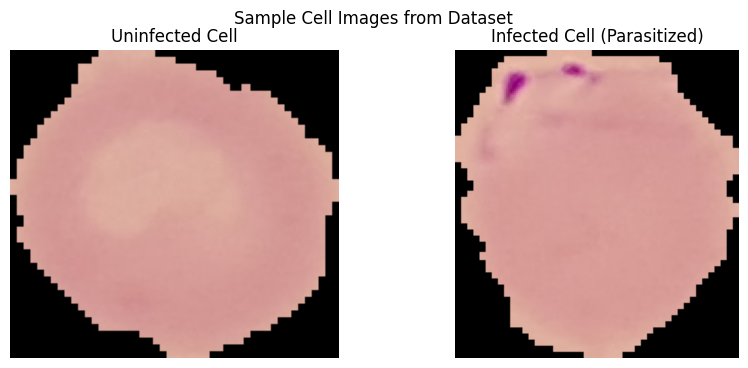

In [ ]:
uninfected_img = '/content/cell-images-for-detecting-malaria/cell_images/Uninfected/C100P61ThinF_IMG_20150918_144104_cell_131.png'
infected_img   = '/content/cell-images-for-detecting-malaria/cell_images/Parasitized/C100P61ThinF_IMG_20150918_144104_cell_164.png'

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(cv2.imread(uninfected_img), cv2.COLOR_BGR2RGB))
plt.title('Uninfected Cell')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(cv2.imread(infected_img), cv2.COLOR_BGR2RGB))
plt.title('Infected Cell (Parasitized)')
plt.axis('off')

plt.suptitle('Sample Cell Images from Dataset')
plt.show()


## Step 4: Clean Dataset (Remove Corrupt Files)

In [ ]:
import os
from PIL import Image

removed = 0
dataset_root = '/content/cell-images-for-detecting-malaria/cell_images/cell_images/'

for folder in os.listdir(dataset_root):
    folder_path = os.path.join(dataset_root, folder)
    if not os.path.isdir(folder_path):
        continue
    for filename in os.listdir(folder_path):
        filepath = os.path.join(folder_path, filename)
        try:
            img = Image.open(filepath)
            img.verify()
        except Exception:
            os.remove(filepath)
            removed += 1

print(f"Corrupt files removed: {removed}")
print("Dataset is clean. Ready for training.")


Corrupt files removed: 2
Dataset is clean. Ready for training.


## Step 5: Prepare Train, Validation and Test Data

In [ ]:
import os
import shutil
import random

original_dataset = '/content/cell-images-for-detecting-malaria/cell_images/'
base_dir = '/content/split_dataset/'

train_dir = os.path.join(base_dir, 'train')
val_dir   = os.path.join(base_dir, 'val')
test_dir  = os.path.join(base_dir, 'test')

classes = ['Parasitized', 'Uninfected']

# Create directories
for dir_path in [train_dir, val_dir, test_dir]:
    for cls in classes:
        os.makedirs(os.path.join(dir_path, cls), exist_ok=True)

# Split data
split_ratio = (0.75, 0.15, 0.15)

for cls in classes:
    cls_path = os.path.join(original_dataset, cls)
    images = os.listdir(cls_path)
    random.shuffle(images)

    total = len(images)
    train_end = int(0.75 * total)
    val_end   = int(0.90 * total)

    train_imgs = images[:train_end]
    val_imgs   = images[train_end:val_end]
    test_imgs  = images[val_end:]

    # Copy files
    for img in train_imgs:
        shutil.copy(os.path.join(cls_path, img),
                    os.path.join(train_dir, cls, img))

    for img in val_imgs:
        shutil.copy(os.path.join(cls_path, img),
                    os.path.join(val_dir, cls, img))

    for img in test_imgs:
        shutil.copy(os.path.join(cls_path, img),
                    os.path.join(test_dir, cls, img))

print("Dataset split complete!")

Dataset split complete!


In [ ]:
IMAGE_SIZE   = (128, 128)
BATCH_SIZE   = 16
DATASET_PATH = '/content/cell-images-for-detecting-malaria/cell_images/cell_images/'

train_datagen = ImageDataGenerator(
    rescale=1/255.0,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1/255.0)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    seed=42
)

val_data = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    seed=42
)

test_data = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False   # IMPORTANT
)

Found 20668 images belonging to 2 classes.
Found 4134 images belonging to 2 classes.
Found 2756 images belonging to 2 classes.


## Step 6: Build the CNN Model

In [ ]:
model = Sequential([

    # Block 1: 16 filters
    Conv2D(16, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    MaxPool2D(2, 2),
    Dropout(0.2),

    # Block 2: 32 filters
    Conv2D(32, (3, 3), activation='relu'),
    MaxPool2D(2, 2),
    Dropout(0.3),

    # Block 3: 64 filters
    Conv2D(64, (3, 3), activation='relu'),
    MaxPool2D(2, 2),
    Dropout(0.3),

    # Fully Connected Layers
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),

    # Output Layer (sigmoid for binary classification)
    Dense(1, activation='sigmoid')
])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       802,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 826,529 (3.15 MB)

 Trainable params: 826,529 (3.15 MB)

 Non-trainable params: 0 (0.00 B)

## Step 7: Compile and Train the Model

In [ ]:
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Stop training early if validation loss stops improving
early_stop = EarlyStopping(monitor='val_loss', patience=2, verbose=1)

history = model.fit(
    train_data,
    epochs=20,
    validation_data=val_data,
    callbacks=[early_stop]
)

print(f"\nTraining complete. Epochs run: {len(history.history['loss'])}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]*100:.2f}%")


Epoch 1/20
1292/1292 ━━━━━━━━━━━━━━━━━━━━ 120s 88ms/step - accuracy: 0.5776 - loss: 0.6722 - val_accuracy: 0.6357 - val_loss: 0.6482
Epoch 2/20
1292/1292 ━━━━━━━━━━━━━━━━━━━━ 106s 82ms/step - accuracy: 0.6707 - loss: 0.6148 - val_accuracy: 0.7027 - val_loss: 0.5773
Epoch 3/20
1292/1292 ━━━━━━━━━━━━━━━━━━━━ 108s 83ms/step - accuracy: 0.7504 - loss: 0.5397 - val_accuracy: 0.8604 - val_loss: 0.4390
Epoch 4/20
1292/1292 ━━━━━━━━━━━━━━━━━━━━ 113s 88ms/step - accuracy: 0.8642 - loss: 0.3694 - val_accuracy: 0.9243 - val_loss: 0.2577
Epoch 5/20
1292/1292 ━━━━━━━━━━━━━━━━━━━━ 105s 82ms/step - accuracy: 0.9102 - loss: 0.2585 - val_accuracy: 0.9037 - val_loss: 0.2233
Epoch 6/20
1292/1292 ━━━━━━━━━━━━━━━━━━━━ 105s 82ms/step - accuracy: 0.9222 - loss: 0.2251 - val_accuracy: 0.9269 - val_loss: 0.2057
Epoch 7/20
1292/1292 ━━━━━━━━━━━━━━━━━━━━ 105s 81ms/step - accuracy: 0.9275 - loss: 0.2135 - val_accuracy: 0.9429 - val_loss: 0.1763
Epoch 8/20
1292/1292 ━━━━━━━━━━━━━━━━━━━━ 108s 84ms/step - accuracy: 

## Step 8: Training Accuracy and Loss Plots

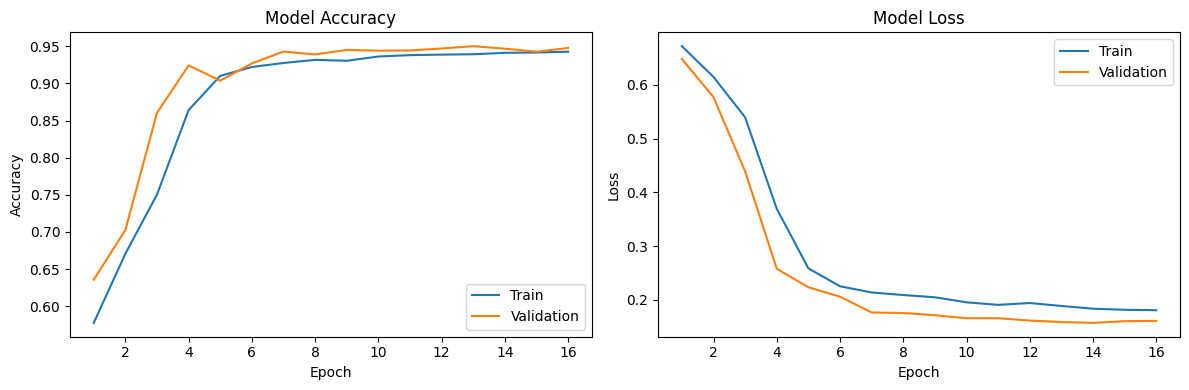

In [ ]:
epochs_run  = len(history.history['loss'])
epoch_range = range(1, epochs_run + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epoch_range, history.history['accuracy'],     label='Train')
plt.plot(epoch_range, history.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epoch_range, history.history['loss'],     label='Train')
plt.plot(epoch_range, history.history['val_loss'], label='Validation')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


## Step 9: Model Evaluation

### 9.1 Confusion Matrix

173/173 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step


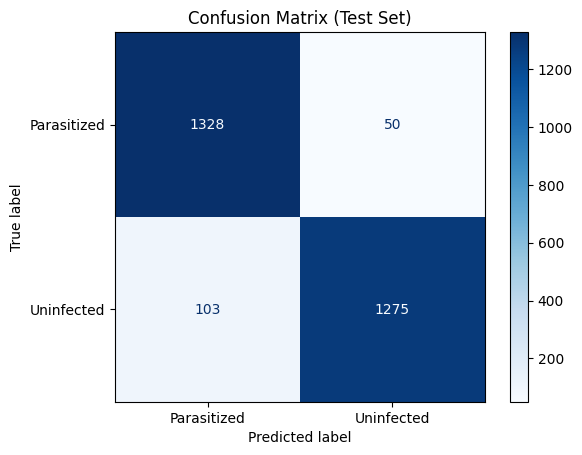

In [ ]:
# Use test dataset
y_pred_prob = model.predict(test_data).flatten()

# Convert probabilities to 0/1
y_pred = (y_pred_prob > 0.5).astype(int)

# True labels
y_true = test_data.classes

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

ConfusionMatrixDisplay(
    cm,
    display_labels=['Parasitized', 'Uninfected']
).plot(cmap='Blues')

plt.title('Confusion Matrix (Test Set)')
plt.show()

### 9.2 Classification Report (Precision, Recall, F1-Score)

In [ ]:
print(classification_report(
    y_true, y_pred,
    target_names=['Parasitized', 'Uninfected']
))


              precision    recall  f1-score   support

 Parasitized       0.93      0.96      0.95      1378
  Uninfected       0.96      0.93      0.94      1378

    accuracy                           0.94      2756
   macro avg       0.95      0.94      0.94      2756
weighted avg       0.95      0.94      0.94      2756



### 9.3 ROC Curve and AUC Score

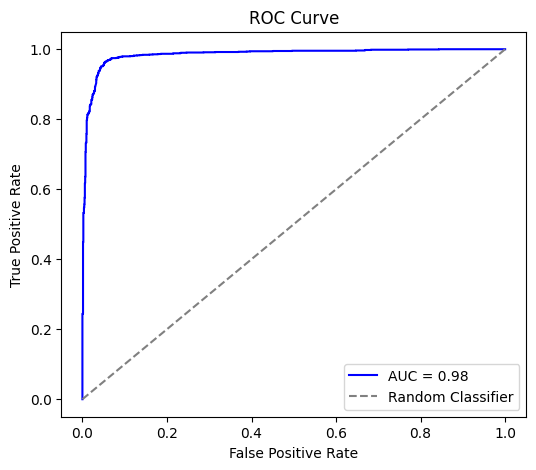

In [ ]:
fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
roc_auc     = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()
